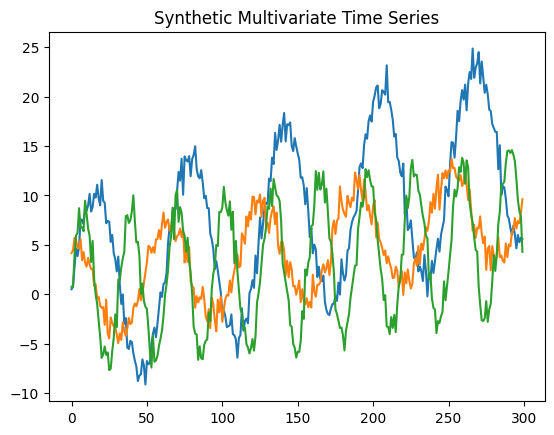

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


Epoch 0, Loss: 0.6016
Epoch 10, Loss: 0.0557
Epoch 20, Loss: 0.0401
Epoch 30, Loss: 0.0264
Epoch 40, Loss: 0.0197
Epoch 50, Loss: 0.0160
Epoch 60, Loss: 0.0154
Epoch 70, Loss: 0.0121
Epoch 80, Loss: 0.0120
Epoch 90, Loss: 0.0109

Test RMSE: 0.0713


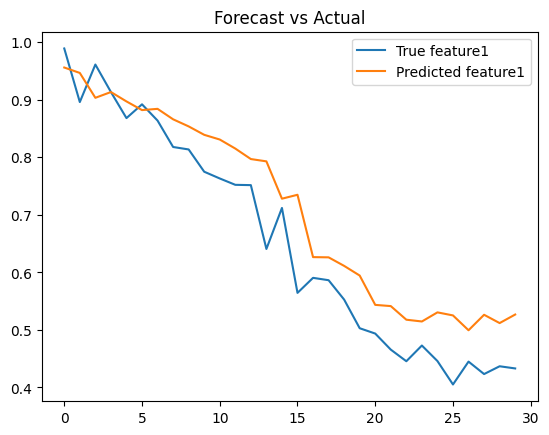

In [2]:
# --- Step 1: Setup ---
!pip install torch numpy pandas matplotlib scikit-learn --quiet

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

# --- Step 2: Generate Synthetic Multivariate Time Series ---
np.random.seed(42)
timesteps = 300
features = 3

# Simulate trend + seasonality + noise
t = np.arange(timesteps)
data = np.stack([
    0.05 * t + 10 * np.sin(0.1 * t) + np.random.normal(0, 1, timesteps),
    0.03 * t + 5 * np.cos(0.1 * t) + np.random.normal(0, 1, timesteps),
    0.02 * t + 8 * np.sin(0.2 * t) + np.random.normal(0, 1, timesteps)
], axis=1)

df = pd.DataFrame(data, columns=["feature1", "feature2", "feature3"])
plt.plot(df)
plt.title("Synthetic Multivariate Time Series")
plt.show()

# --- Step 3: Preprocessing ---
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df)

def create_sequences(data, seq_len):
    xs, ys = [], []
    for i in range(len(data) - seq_len):
        x = data[i:i+seq_len]
        y = data[i+seq_len]
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys)

seq_len = 20
X, y = create_sequences(scaled_data, seq_len)

X_train = torch.tensor(X[:250], dtype=torch.float32)
y_train = torch.tensor(y[:250], dtype=torch.float32)
X_test = torch.tensor(X[250:], dtype=torch.float32)
y_test = torch.tensor(y[250:], dtype=torch.float32)

# --- Step 4: Transformer Model ---
class TimeSeriesTransformer(nn.Module):
    def __init__(self, input_size, d_model=64, nhead=4, num_layers=2):
        super().__init__()
        self.embedding = nn.Linear(input_size, d_model)
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fc = nn.Linear(d_model, input_size)

    def forward(self, x):
        x = self.embedding(x)
        x = self.transformer(x)
        x = x[-1]  # use last time step
        return self.fc(x)

model = TimeSeriesTransformer(input_size=3)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# --- Step 5: Training ---
for epoch in range(100):
    model.train()
    output = model(X_train.transpose(0, 1))
    loss = criterion(output, y_train)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

# --- Step 6: Evaluation ---
model.eval()
with torch.no_grad():
    preds = model(X_test.transpose(0, 1)).numpy()
    true = y_test.numpy()

rmse = np.sqrt(mean_squared_error(true, preds))
print(f"\nTest RMSE: {rmse:.4f}")

# --- Step 7: Plot Predictions ---
plt.plot(true[:, 0], label="True feature1")
plt.plot(preds[:, 0], label="Predicted feature1")
plt.legend()
plt.title("Forecast vs Actual")
plt.show()